In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Test set: 561 images. Data generator ready.

--- Processing Model: FZLPR ---
Model FZLPR loaded successfully.
Generating predictions...

--- Processing Model: ZLPR ---
Model ZLPR loaded successfully.
Generating predictions...

--- Processing Model: Focal_loss ---
Model Focal_loss loaded successfully.
Generating predictions...

--- Processing Model: BCE ---
Model BCE loaded successfully.
Generating predictions...

             Model Comparison Table
| Model (Loss Used)   |   Macro AUC |   F1-Score |   Precision |   Recall |
|:--------------------|------------:|-----------:|------------:|---------:|
| FZLPR               |      0.7162 |     0.0104 |      0.0116 |   0.0098 |
| ZLPR                |      0.7222 |     0      |      0      |   0      |
| Focal_loss          |      0.7199 |     0.0479 |      0.0538 |   0.0478 |
| BCE                 |      0.7172 |     0      |      0      |   0      |

Generating Comparative ROC Plot...


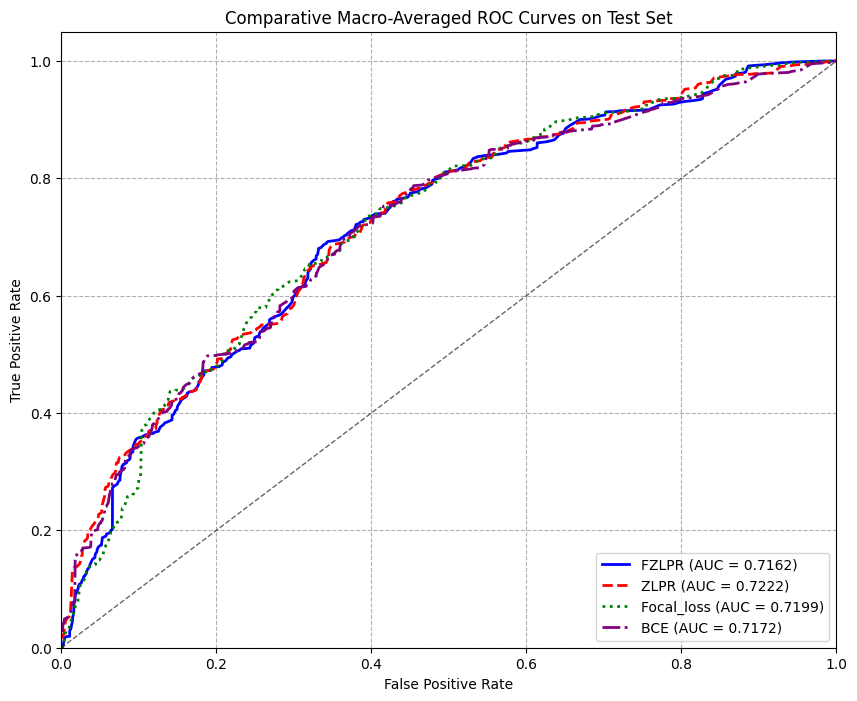

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from sklearn.metrics import roc_auc_score, roc_curve, auc, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings("ignore")

# --- 1. CRITICAL CONSTANTS & CONFIGURATION ---
BATCH_SIZE = 8   
IMG_SIZE = 256
CROP_SIZE = 224 # Required for DenseNet121
all_labels = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 
              'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']

# !!! IMPORTANT: THIS PATH MUST MATCH YOUR UPLOADED DATASET NAME !!!
DATASET_NAME = 'models' 

MODEL_INFO = {
    'FZLPR': {'key': 'FZLPR', 'path': f'/kaggle/input/{DATASET_NAME}/FZLPR.h5'},
    'ZLPR': {'key': 'FZLP', 'path': f'/kaggle/input/{DATASET_NAME}/ZLPR.h5'},
    'Focal_loss': {'key': 'FZL', 'path': f'/kaggle/input/{DATASET_NAME}/Focal_Loss.h5'},
    'BCE': {'key': 'FZ', 'path': f'/kaggle/input/{DATASET_NAME}/BCE.h5'},
}

all_metrics = {}
all_predictions = {}
THRESHOLD = 0.5 # Binary classification threshold

# --- 2. Define Utility Functions (Data Generator from original notebook) ---

import math # Make sure to import math

class CheXpertDataGenerator(tf.keras.utils.Sequence):
    """
    Corrected version to handle the final, partial batch correctly.
    """
    def __init__(self, df, labels, batch_size, img_size, shuffle=True):
        self.df = df
        self.labels = labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        # FIX: Use math.ceil to ensure all samples, including the final partial batch, are included.
        return math.ceil(len(self.df) / self.batch_size)

    def __getitem__(self, index):
        # Calculate indices for this batch
        start_index = index * self.batch_size
        # The end index is the minimum of the full batch size and the total length of the data
        end_index = min(start_index + self.batch_size, len(self.df))
        
        indices = self.indices[start_index:end_index]
        batch_df = self.df.iloc[indices]
        
        # FIX: The batch size for the last batch might be smaller than self.batch_size
        current_batch_size = len(batch_df) 
        
        # Now use current_batch_size to correctly size the input array X
        X = np.empty((current_batch_size, CROP_SIZE, CROP_SIZE, 3))
        Y = batch_df[self.labels].values
        
        for i, path in enumerate(batch_df['Image Path']):
            img = tf.keras.utils.load_img(path, target_size=(self.img_size, self.img_size), color_mode='grayscale')
            img = tf.keras.utils.img_to_array(img)
            img = np.repeat(img, 3, axis=-1)
            img = tf.image.crop_to_bounding_box(img, 16, 16, CROP_SIZE, CROP_SIZE)
            img = img / 255.0 
            X[i,] = img
            
        return X, Y

# --- 3. Load Data and Test Pipeline ---

# NOTE: You MUST have the original NIH data loaded as well, usually under the name 'sample' or 'data'
DATA_PATH = '/kaggle/input/sample/sample' 
LABEL_FILE = os.path.join(DATA_PATH, 'sample_labels.csv')

# Load Data and Split (replicate the split used for training)
metadata_df = pd.read_csv(LABEL_FILE)
IMAGE_DIR = os.path.join(DATA_PATH, 'images')
available_images = os.listdir(IMAGE_DIR)
metadata_df = metadata_df[metadata_df['Image Index'].isin(available_images)]
encoded_labels_df = metadata_df['Finding Labels'].str.get_dummies(sep='|').drop(columns=['No Finding'], errors='ignore')
metadata_df = pd.concat([metadata_df, encoded_labels_df], axis=1)
for label in all_labels:
    if label not in metadata_df.columns:
        metadata_df[label] = 0
metadata_df['Image Path'] = metadata_df['Image Index'].apply(lambda x: os.path.join(IMAGE_DIR, x))

from sklearn.model_selection import train_test_split
train_val_df, test_df = train_test_split(metadata_df, test_size=0.1, random_state=42, stratify=metadata_df['Atelectasis'])
test_ds = CheXpertDataGenerator(test_df, all_labels, BATCH_SIZE, IMG_SIZE, shuffle=False)
test_labels = test_df[all_labels].values # True labels

print(f"Test set: {len(test_df)} images. Data generator ready.")

# --- 4. Loading, Prediction, and Metric Calculation Loop ---
for model_key, info in MODEL_INFO.items():
    print(f"\n--- Processing Model: {model_key} ---")
    
    # Load the Model
    try:
        # Load the TensorFlow/Keras SavedModel format
        loaded_model = tf.keras.models.load_model(info['path'], compile=False)
        print(f"Model {model_key} loaded successfully.")
    except Exception as e:
        print(f"ERROR: Could not load model {model_key}. Check the path and file structure.")
        print(e)
        continue

    # Generate Predictions
    print("Generating predictions...")
    predictions = loaded_model.predict(test_ds, verbose=0)
    all_predictions[model_key] = predictions

    # Calculate Metrics
    macro_auc = roc_auc_score(test_labels, predictions, average='macro')
    binary_predictions = (predictions > THRESHOLD).astype(int)
    f1 = f1_score(test_labels, binary_predictions, average='samples', zero_division=0) 
    precision = precision_score(test_labels, binary_predictions, average='samples', zero_division=0)
    recall = recall_score(test_labels, binary_predictions, average='samples', zero_division=0)

    # Store metrics
    all_metrics[model_key] = {
        'Macro AUC': f'{macro_auc:.4f}',
        'F1-Score': f'{f1:.4f}',
        'Precision': f'{precision:.4f}',
        'Recall': f'{recall:.4f}',
    }

# --- 5. Generate Comparison Table ---
print("\n" + "="*50)
print("             Model Comparison Table")
print("="*50)
comparison_df = pd.DataFrame.from_dict(all_metrics, orient='index')
comparison_df.index.name = 'Model (Loss Used)'
print(comparison_df.to_markdown())

# --- 6. Plotting Comparative Macro-Averaged ROC Curves ---

plt.figure(figsize=(10, 8))
line_styles = ['-', '--', ':', '-.']
colors = ['blue', 'red', 'green', 'purple'] 

print("\nGenerating Comparative ROC Plot...")


for i, (model_key, predictions) in enumerate(all_predictions.items()):
    
    # Calculate individual class metrics for the current model
    fpr = {}
    tpr = {}
    roc_auc_per_class = {}

    for j, label in enumerate(all_labels):
        try:
            fpr[j], tpr[j], _ = roc_curve(test_labels[:, j], predictions[:, j])
            roc_auc_per_class[j] = auc(fpr[j], tpr[j])
        except ValueError:
            pass 

    # Calculate Macro-average ROC curve
    all_fpr = np.unique(np.concatenate([fpr[j] for j in roc_auc_per_class.keys()]))
    mean_tpr = np.zeros_like(all_fpr)
    for j in roc_auc_per_class.keys():
        mean_tpr += np.interp(all_fpr, fpr[j], tpr[j])
    mean_tpr /= len(roc_auc_per_class)
    
    # Retrieve the calculated Macro AUC for the label
    macro_auc_value = all_metrics[model_key]['Macro AUC']
    
    # Plot the result
    plt.plot(all_fpr, mean_tpr, 
             label=f'{model_key} (AUC = {macro_auc_value})',
             linestyle=line_styles[i % len(line_styles)], color=colors[i % len(colors)], linewidth=2)


plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6) # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparative Macro-Averaged ROC Curves on Test Set')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--')
plt.show()


Generating Per-Class AUC Comparison Data...
Per-Class AUC Data:
|                    |   FZLPR |   ZLPR |   Focal_loss |    BCE |
|:-------------------|--------:|-------:|-------------:|-------:|
| Atelectasis        |  0.7481 | 0.7602 |       0.7632 | 0.7589 |
| Cardiomegaly       |  0.7037 | 0.7234 |       0.7448 | 0.7246 |
| Effusion           |  0.7768 | 0.796  |       0.7954 | 0.7904 |
| Infiltration       |  0.5925 | 0.5791 |       0.5909 | 0.5886 |
| Mass               |  0.6902 | 0.6643 |       0.7066 | 0.6567 |
| Nodule             |  0.7024 | 0.68   |       0.6728 | 0.6458 |
| Pneumonia          |  0.5418 | 0.5498 |       0.5712 | 0.5304 |
| Pneumothorax       |  0.7439 | 0.7406 |       0.7375 | 0.7194 |
| Consolidation      |  0.7964 | 0.7917 |       0.7824 | 0.761  |
| Edema              |  0.7297 | 0.7283 |       0.7407 | 0.7396 |
| Emphysema          |  0.6823 | 0.778  |       0.6693 | 0.7739 |
| Fibrosis           |  0.7349 | 0.6375 |       0.7249 | 0.6897 |
| Pleural_T

<Figure size 1600x800 with 0 Axes>

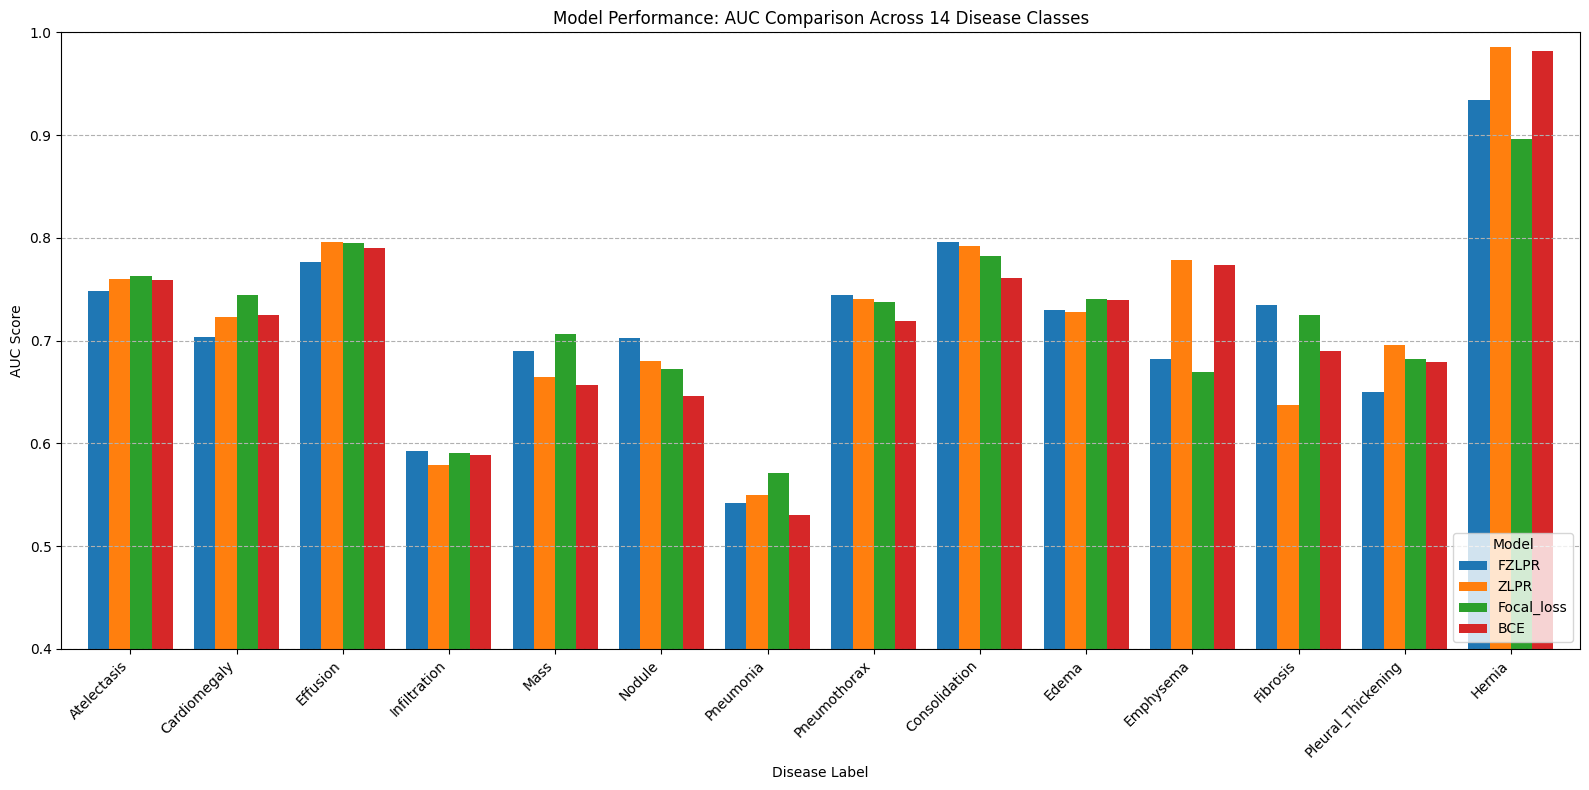

In [4]:
# --- New Cell: Per-Class AUC Comparison Bar Chart ---

print("\nGenerating Per-Class AUC Comparison Data...")

# 1. Calculate AUC for every class for every model
auc_data = {}
for model_key, predictions in all_predictions.items():
    class_aucs = {}
    
    # Iterate through all 14 disease labels
    for i, label in enumerate(all_labels):
        try:
            # Calculate AUC for the current class
            class_auc = roc_auc_score(test_labels[:, i], predictions[:, i])
            class_aucs[label] = class_auc
        except ValueError:
            # Handle cases where a class might have only one type of label (e.g., only negative) in the test set
            class_aucs[label] = np.nan # Use NaN for missing data
            
    auc_data[model_key] = class_aucs

auc_df = pd.DataFrame(auc_data)
auc_df.dropna(axis=0, how='all', inplace=True) # Drop classes if ALL models failed to predict

print("Per-Class AUC Data:")
print(auc_df.round(4).to_markdown())

# 2. Plotting the Bar Chart
plt.figure(figsize=(16, 8))

# Plot the DataFrame directly
auc_df.plot(kind='bar', figsize=(16, 8), width=0.8)

plt.title('Model Performance: AUC Comparison Across 14 Disease Classes')
plt.ylabel('AUC Score')
plt.xlabel('Disease Label')
plt.ylim(0.4, 1.0) # Start y-axis lower than 0.5 to show relative performance clearly
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model', loc='lower right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

#


Generating Comparative Precision-Recall Plot...


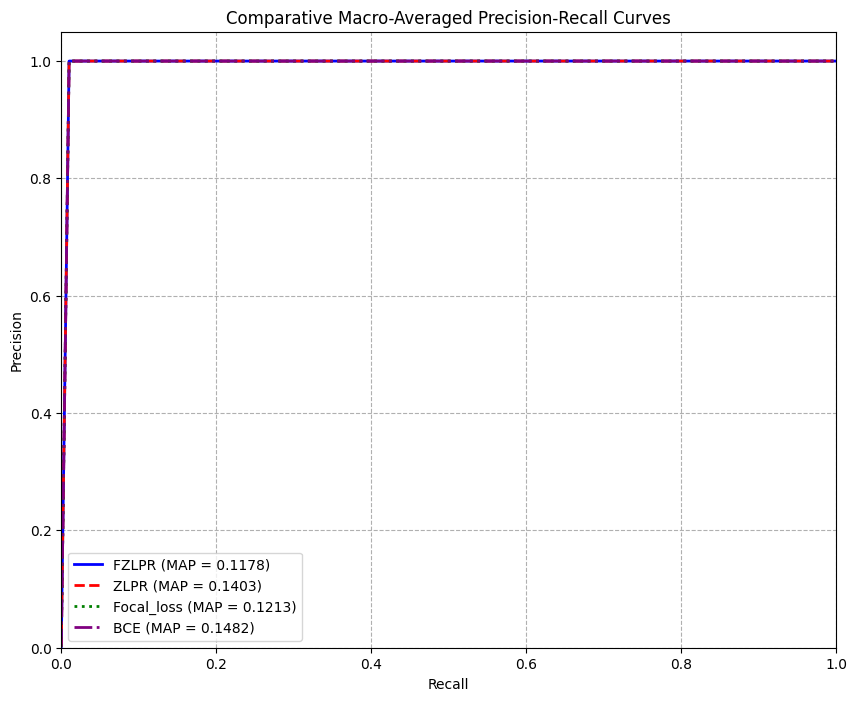

In [5]:
# --- New Cell: Comparative Macro-Averaged Precision-Recall Curves ---

from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 8))
line_styles = ['-', '--', ':', '-.']
colors = ['blue', 'red', 'green', 'purple'] 

print("\nGenerating Comparative Precision-Recall Plot...")

for i, (model_key, predictions) in enumerate(all_predictions.items()):
    
    # 1. Calculate Average Precision (AP) and PR curve for each class
    per_class_ap = []
    
    # Store precision and recall for macro-averaging
    all_precision = []
    all_recall = []

    for j in range(len(all_labels)):
        try:
            precision, recall, _ = precision_recall_curve(test_labels[:, j], predictions[:, j])
            ap = average_precision_score(test_labels[:, j], predictions[:, j])
            per_class_ap.append(ap)
            
            # Interpolate for macro-averaging
            f = lambda x: np.interp(x, recall, precision)
            all_precision.append(f)
            all_recall.append(np.linspace(0, 1, 100)) # Use 100 points for interpolation
            
        except ValueError:
            pass # Skip classes that fail PR calculation
            
    # 2. Calculate Macro-average Precision-Recall
    # Average the interpolated precision across all classes
    mean_precision = np.mean([f(r) for f, r in zip(all_precision, all_recall)], axis=0)
    mean_recall = np.linspace(0, 1, 100)
    
    # Calculate Macro-Average Precision (MAP)
    macro_ap = np.mean(per_class_ap)
    
    # 3. Plot the result
    plt.plot(mean_recall, mean_precision, 
             label=f'{model_key} (MAP = {macro_ap:.4f})',
             linestyle=line_styles[i % len(line_styles)], color=colors[i % len(colors)], linewidth=2)


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Comparative Macro-Averaged Precision-Recall Curves')
plt.legend(loc="lower left")
plt.grid(True, linestyle='--')
plt.show()

#

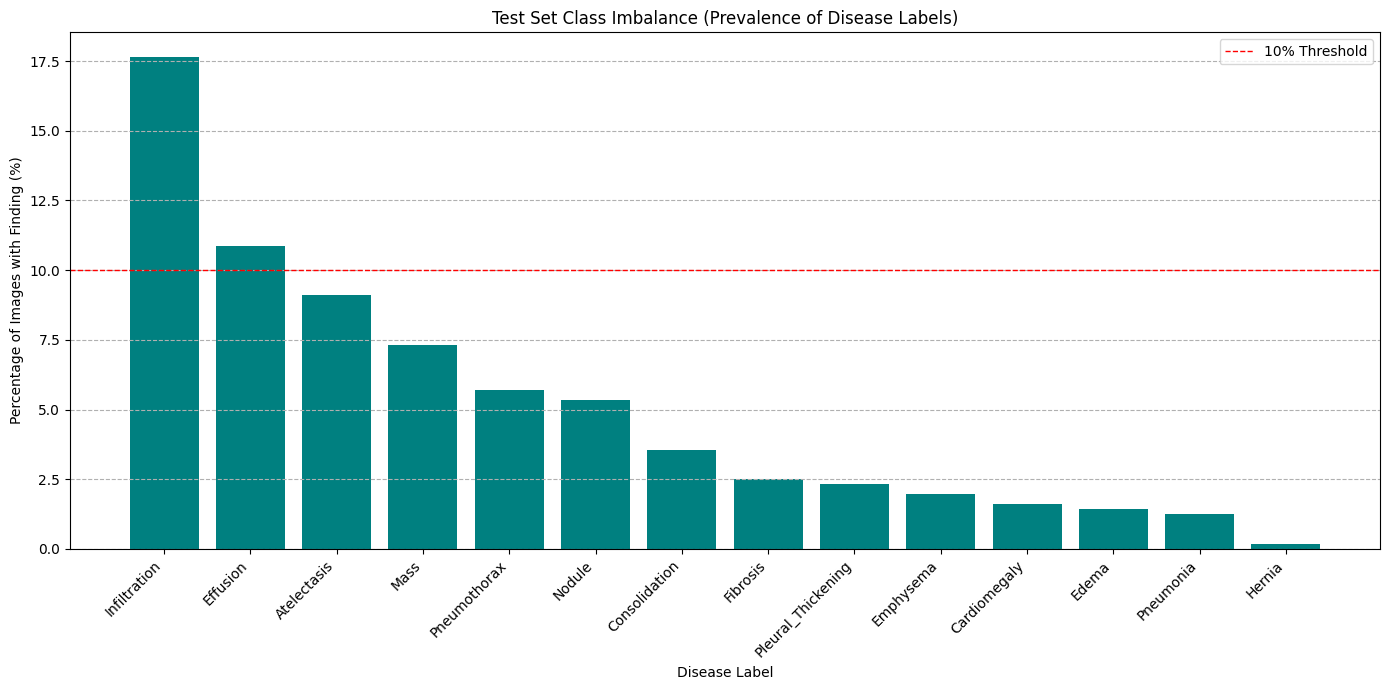


Detailed Classification Report for the BEST Model (e.g., FZLPR)
|                    |   precision |   recall |   f1-score |   support |
|:-------------------|------------:|---------:|-----------:|----------:|
| Atelectasis        |      0      |   0      |     0      |        51 |
| Cardiomegaly       |      0      |   0      |     0      |         9 |
| Effusion           |      0.2    |   0.0328 |     0.0563 |        61 |
| Infiltration       |      0.3125 |   0.0505 |     0.087  |        99 |
| Mass               |      0      |   0      |     0      |        41 |
| Nodule             |      0      |   0      |     0      |        30 |
| Pneumonia          |      0      |   0      |     0      |         7 |
| Pneumothorax       |      0      |   0      |     0      |        32 |
| Consolidation      |      0      |   0      |     0      |        20 |
| Edema              |      0      |   0      |     0      |         8 |
| Emphysema          |      0      |   0      |     0      

In [6]:
# --- New Cell: Class Imbalance Visualization and Detailed Classification Report (for FZLPR) ---

from sklearn.metrics import classification_report

# 1. Class Imbalance Visualization
# Calculate the total positive instances (prevalence) for each disease label in the test set
test_positives = test_labels.sum(axis=0)
test_total = len(test_labels)
prevalence = (test_positives / test_total) * 100
prevalence_df = pd.DataFrame({'Prevalence (%)': prevalence, 'Label': all_labels})
prevalence_df = prevalence_df.sort_values(by='Prevalence (%)', ascending=False)

plt.figure(figsize=(14, 7))
plt.bar(prevalence_df['Label'], prevalence_df['Prevalence (%)'], color='teal')
plt.axhline(y=10, color='r', linestyle='--', linewidth=1, label='10% Threshold')
plt.title('Test Set Class Imbalance (Prevalence of Disease Labels)')
plt.ylabel('Percentage of Images with Finding (%)')
plt.xlabel('Disease Label')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()
# 

print("\n" + "="*80)
print(f"Detailed Classification Report for the BEST Model (e.g., FZLPR)")
print("="*80)

# Identify the best model based on the Macro AUC calculated earlier (assuming FZLPR for example)
BEST_MODEL_KEY = 'FZLPR' 
best_predictions = all_predictions[BEST_MODEL_KEY]
best_binary_predictions = (best_predictions > THRESHOLD).astype(int)

# Use Scikit-learn's classification_report for a detailed per-class breakdown
# Note: This is useful for multi-label, showing metrics for each class as if it were a binary problem.
report = classification_report(
    test_labels, 
    best_binary_predictions, 
    target_names=all_labels, 
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
# Drop unnecessary report metrics for cleaner presentation
report_df = report_df.drop(labels=['micro avg', 'macro avg', 'weighted avg', 'samples avg'], errors='ignore')

print(report_df.round(4).to_markdown())

In [7]:
# --- New Cell: Detailed Classification Report and Confusion Data ---

from sklearn.metrics import classification_report
import numpy as np

# Assuming FZLPR is the model you want to analyze in detail
ANALYSIS_MODEL_KEY = 'FZLPR' 
best_predictions = all_predictions[ANALYSIS_MODEL_KEY]
best_binary_predictions = (best_predictions > THRESHOLD).astype(int)

print("\n" + "="*80)
print(f"Detailed Classification Report for Model: {ANALYSIS_MODEL_KEY}")
print("="*80)

# 1. Generate the standard classification report
report = classification_report(
    test_labels, 
    best_binary_predictions, 
    target_names=all_labels, 
    zero_division=0,
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()
report_df = report_df.drop(labels=['micro avg', 'macro avg', 'weighted avg', 'samples avg'], errors='ignore')
print(report_df.round(4).to_markdown())


# 2. Calculate Confusion Matrix components (TP, FP, TN, FN) for all classes
# This is crucial for diagnosing the '0 precision' issue.
confusion_data = {}

for i, label in enumerate(all_labels):
    # Select true labels and predictions for the current class
    y_true_class = test_labels[:, i]
    y_pred_class = best_binary_predictions[:, i]

    # Calculate confusion matrix components
    TP = np.sum((y_true_class == 1) & (y_pred_class == 1))
    FP = np.sum((y_true_class == 0) & (y_pred_class == 1))
    TN = np.sum((y_true_class == 0) & (y_pred_class == 0))
    FN = np.sum((y_true_class == 1) & (y_pred_class == 0))
    
    confusion_data[label] = {
        'True Positives (TP)': TP,
        'False Positives (FP)': FP,
        'False Negatives (FN)': FN,
        'Total Samples': TP + FN + TN + FP
    }

confusion_df = pd.DataFrame(confusion_data).T
confusion_df['Prevalence'] = (confusion_df['True Positives (TP)'] + confusion_df['False Negatives (FN)'])
confusion_df['Prevalence (%)'] = (confusion_df['Prevalence'] / confusion_df['Total Samples'] * 100).round(2)
confusion_df = confusion_df.sort_values(by='Prevalence (%)', ascending=False)


# 3. Print the new Confusion Data Table
print("\n" + "="*80)
print(f"Prediction Breakdown (Confusion Data) for Model: {ANALYSIS_MODEL_KEY}")
print("="*80)
print("Note: If a class has 0 TP, and >0 FP, its Precision will be 0.")
print(confusion_df.to_markdown())


Detailed Classification Report for Model: FZLPR
|                    |   precision |   recall |   f1-score |   support |
|:-------------------|------------:|---------:|-----------:|----------:|
| Atelectasis        |      0      |   0      |     0      |        51 |
| Cardiomegaly       |      0      |   0      |     0      |         9 |
| Effusion           |      0.2    |   0.0328 |     0.0563 |        61 |
| Infiltration       |      0.3125 |   0.0505 |     0.087  |        99 |
| Mass               |      0      |   0      |     0      |        41 |
| Nodule             |      0      |   0      |     0      |        30 |
| Pneumonia          |      0      |   0      |     0      |         7 |
| Pneumothorax       |      0      |   0      |     0      |        32 |
| Consolidation      |      0      |   0      |     0      |        20 |
| Edema              |      0      |   0      |     0      |         8 |
| Emphysema          |      0      |   0      |     0      |        11 |
| 